In [15]:
#===================================
#
# Image Classification System Model
#
# MLOps Project
#
# Pablo Rodriguez
#
#
#

In [16]:
import json
from pathlib import Path

import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [17]:
digits = load_digits()

images = digits.images
X = digits.data
y = digits.target

print("Images:", images.shape)
print("Features:", X.shape)
print("Labels:", y.shape)
print("Classes:", digits.target_names)

Images: (1797, 8, 8)
Features: (1797, 64)
Labels: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


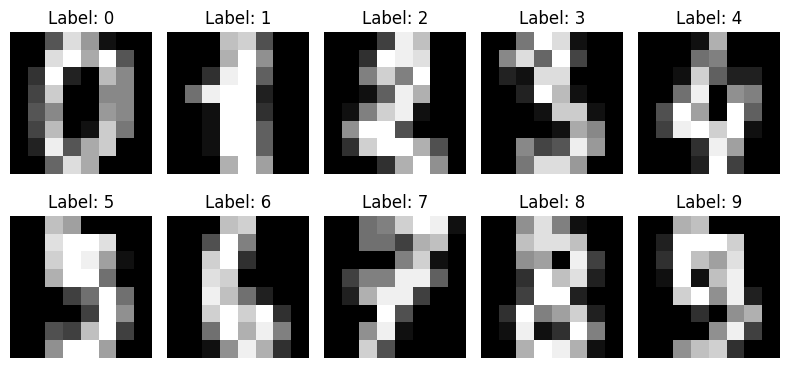

In [18]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i],
        cmap="gray"
    )

    plt.title(
        f"Label: {y[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
X = X / 16.0

print(
    "Pixel range:",
    X.min(),
    "to",
    X.max()
)

Pixel range: 0.0 to 1.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training images:",
    len(X_train)
)

print(
    "Test images:",
    len(X_test)
)

Training images: 1437
Test images: 360


In [21]:
model = LogisticRegression(
    max_iter=2000
)

model.fit(
    X_train,
    y_train
)

print("Model trained.")

Model trained.


In [22]:
predictions = model.predict(
    X_test
)

probabilities = model.predict_proba(
    X_test
)

confidence = probabilities.max(
    axis=1
)

print(
    "Predictions:",
    len(predictions)
)

Predictions: 360


In [23]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"Accuracy: {accuracy:.2%}"
)

Accuracy: 95.56%


In [24]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.88      0.83      0.86        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.92      1.00      0.96        36
           5       0.97      1.00      0.99        37
           6       0.97      0.94      0.96        36
           7       0.97      1.00      0.99        36
           8       0.91      0.89      0.90        35
           9       0.94      0.92      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.95       360
weighted avg       0.96      0.96      0.96       360



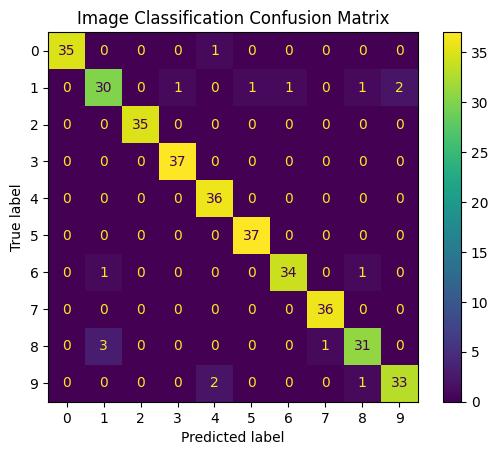

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title(
    "Image Classification Confusion Matrix"
)

plt.show()

Incorrect predictions: 16


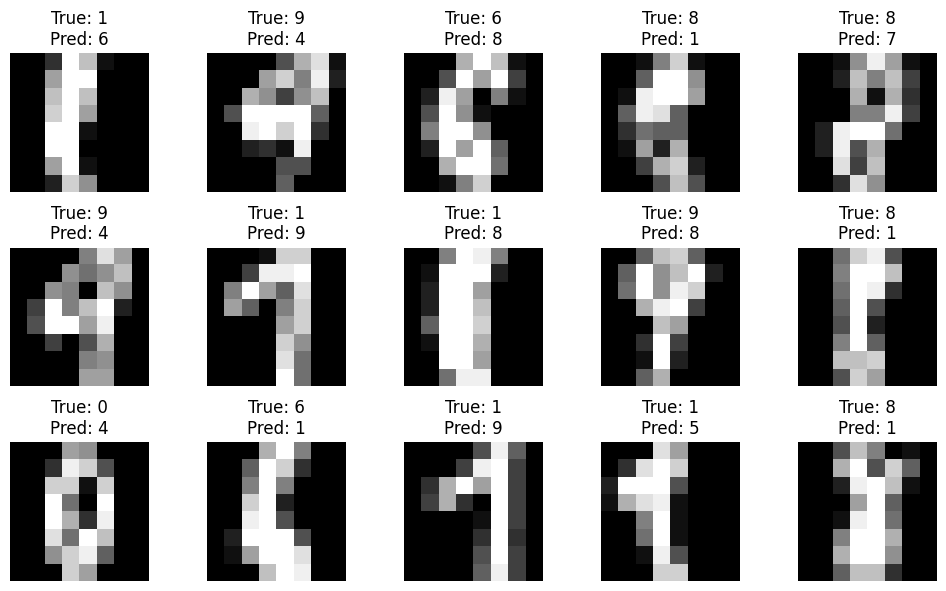

In [26]:
wrong = np.where(
    predictions != y_test
)[0]

print(
    "Incorrect predictions:",
    len(wrong)
)

n = min(
    15,
    len(wrong)
)

if n > 0:

    plt.figure(
        figsize=(10, 6)
    )

    for position, index in enumerate(
        wrong[:n]
    ):

        plt.subplot(
            3,
            5,
            position + 1
        )

        plt.imshow(
            X_test[index].reshape(
                8,
                8
            ),
            cmap="gray"
        )

        plt.title(
            f"True: {y_test[index]}\n"
            f"Pred: {predictions[index]}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [27]:
print(
    "Average confidence:",
    f"{confidence.mean():.2%}"
)

print(
    "Minimum confidence:",
    f"{confidence.min():.2%}"
)

print(
    "Maximum confidence:",
    f"{confidence.max():.2%}"
)

Average confidence: 90.18%
Minimum confidence: 28.28%
Maximum confidence: 99.91%


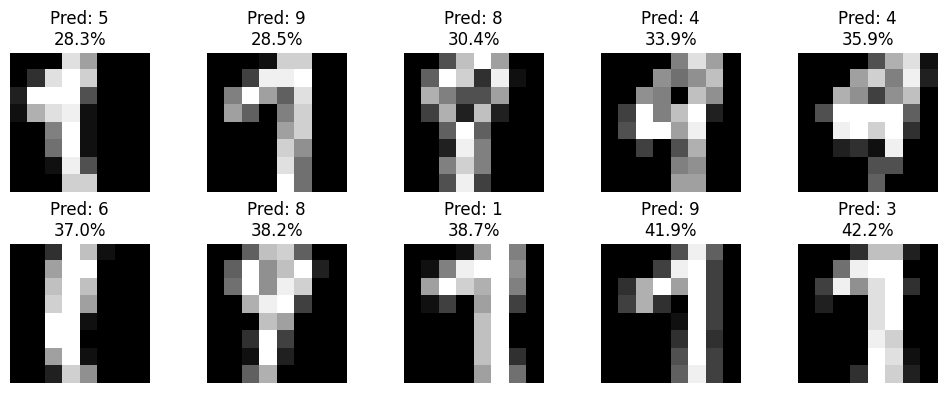

In [28]:
lowest = np.argsort(
    confidence
)[:10]

plt.figure(
    figsize=(10, 4)
)

for position, index in enumerate(
    lowest
):

    plt.subplot(
        2,
        5,
        position + 1
    )

    plt.imshow(
        X_test[index].reshape(
            8,
            8
        ),
        cmap="gray"
    )

    plt.title(
        f"Pred: {predictions[index]}\n"
        f"{confidence[index]:.1%}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
correct = (
    predictions == y_test
)

print(
    "Average confidence when correct:",
    f"{confidence[correct].mean():.2%}"
)

print(
    "Average confidence when incorrect:",
    f"{confidence[~correct].mean():.2%}"
)

Average confidence when correct: 92.21%
Average confidence when incorrect: 46.49%


In [30]:
ARTIFACT_DIR = Path(
    "image_classifier_artifacts"
)

ARTIFACT_DIR.mkdir(
    exist_ok=True
)

MODEL_PATH = (
    ARTIFACT_DIR
    / "digit_classifier.joblib"
)

joblib.dump(
    model,
    MODEL_PATH
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: image_classifier_artifacts/digit_classifier.joblib


In [31]:
metadata = {
    "model": "LogisticRegression",
    "dataset": "sklearn_digits",
    "image_shape": [8, 8],
    "classes": digits.target_names.tolist(),
    "normalization": "pixel / 16.0",
    "training_images": len(X_train),
    "test_images": len(X_test),
    "accuracy": float(accuracy),
    "average_confidence": float(
        confidence.mean()
    )
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    "Saved:",
    METADATA_PATH
)

Saved: image_classifier_artifacts/metadata.json


In [32]:
def smoke_test():

    # Dataset
    assert images.ndim == 3

    assert images.shape[1:] == (
        8,
        8
    )

    assert X.shape[1] == 64

    # Normalization
    assert X.min() >= 0
    assert X.max() <= 1

    # Classes
    assert len(
        np.unique(y)
    ) == 10

    # Split
    assert len(X_train) > 0
    assert len(X_test) > 0

    # Predictions
    assert (
        predictions.shape
        ==
        y_test.shape
    )

    # Metrics
    assert (
        0
        <= accuracy
        <= 1
    )

    assert np.all(
        (confidence >= 0)
        &
        (confidence <= 1)
    )

    # Artifacts
    assert MODEL_PATH.exists()
    assert METADATA_PATH.exists()

    # Reload model
    loaded_model = joblib.load(
        MODEL_PATH
    )

    loaded_predictions = (
        loaded_model.predict(
            X_test
        )
    )

    assert np.array_equal(
        predictions,
        loaded_predictions
    )

    print(
        "✅ Image classification pipeline passed."
    )


smoke_test()

✅ Image classification pipeline passed.
